In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

target_dir = r"C:\Users\Emrullah\Desktop\DerinOgrenmeProje"
try:
    os.chdir(target_dir)
    print(f"Current Directory: {os.getcwd()}")
except FileNotFoundError:
    print("Target directory not found. Using current directory.")

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Current Directory: C:\Users\Emrullah\Desktop\DerinOgrenmeProje
Device: cuda
NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
TRAIN_DIR = "./dataset/train"
TEST_DIR = "./dataset/test"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

if not os.path.exists(TRAIN_DIR):
    print(f"Error: {TRAIN_DIR} not found.")
else:
    train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
    test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=transform)
    classes = train_dataset.classes
    print(f"Classes: {classes}")
    print(f"Train Images: {len(train_dataset)}")
    print(f"Test Images: {len(test_dataset)}")

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']
Train Images: 119400
Test Images: 47796


In [3]:
class CustomShallowCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomShallowCNN, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.flatten(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [4]:
def train_eval_loop(batch_size, epochs=3):
    print(f"Starting Training... Batch Size: {batch_size}")
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    
    model = CustomShallowCNN(num_classes=len(classes)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    loss_history = []
    model.train()
    start_time = time.time()
    total_steps = len(train_loader)
    
    for epoch in range(epochs):
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if (i+1) % 100 == 0:
                print(f"Epoch {epoch+1} Step {i+1}/{total_steps} Loss: {loss.item():.4f}")
            
        epoch_loss = running_loss / total_steps
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1} Finished. Avg Loss: {epoch_loss:.4f}")
        
    duration = time.time() - start_time
    print(f"Total Time: {duration:.2f}s")
    
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return loss_history, all_labels, all_preds

batch_sizes = [32, 64, 128]
results = {}

if 'classes' in globals():
    for bs in batch_sizes:
        lh, true_y, pred_y = train_eval_loop(bs, epochs=3)
        results[bs] = {'loss': lh, 'true': true_y, 'pred': pred_y}

Starting Training... Batch Size: 32
Epoch 1 Step 100/3732 Loss: 2.8134
Epoch 1 Step 200/3732 Loss: 2.6213
Epoch 1 Step 300/3732 Loss: 2.2841
Epoch 1 Step 400/3732 Loss: 2.1975
Epoch 1 Step 500/3732 Loss: 2.0291
Epoch 1 Step 600/3732 Loss: 1.2809
Epoch 1 Step 700/3732 Loss: 1.4547
Epoch 1 Step 800/3732 Loss: 1.6205
Epoch 1 Step 900/3732 Loss: 1.5057
Epoch 1 Step 1000/3732 Loss: 1.2133
Epoch 1 Step 1100/3732 Loss: 0.9373
Epoch 1 Step 1200/3732 Loss: 1.3809
Epoch 1 Step 1300/3732 Loss: 1.5093
Epoch 1 Step 1400/3732 Loss: 0.9630
Epoch 1 Step 1500/3732 Loss: 0.8275
Epoch 1 Step 1600/3732 Loss: 1.1961
Epoch 1 Step 1700/3732 Loss: 0.8455
Epoch 1 Step 1800/3732 Loss: 1.1435
Epoch 1 Step 1900/3732 Loss: 1.0414
Epoch 1 Step 2000/3732 Loss: 0.6885
Epoch 1 Step 2100/3732 Loss: 0.9122
Epoch 1 Step 2200/3732 Loss: 0.7246
Epoch 1 Step 2300/3732 Loss: 0.6373
Epoch 1 Step 2400/3732 Loss: 0.6920
Epoch 1 Step 2500/3732 Loss: 0.7972
Epoch 1 Step 2600/3732 Loss: 0.8339
Epoch 1 Step 2700/3732 Loss: 1.0021
E

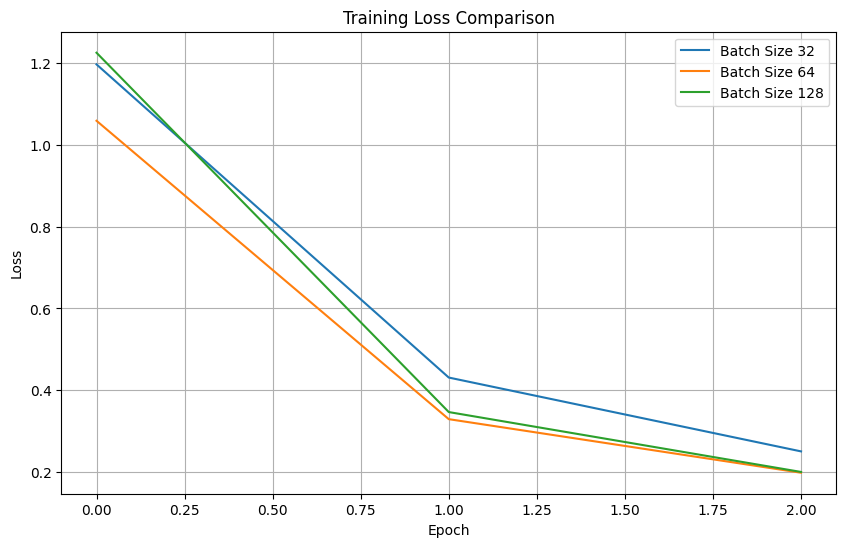

Best Batch Size: 64 (F1-Score: 0.9499)
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.96      0.91      0.94      1962
           B       0.97      0.98      0.98      1929
           C       0.95      0.98      0.96      1953
           D       0.94      0.92      0.93      1948
           E       0.95      0.98      0.96      1943
           F       0.97      0.96      0.96      1973
           G       0.91      0.98      0.94      1947
           H       0.91      0.97      0.94      1952
           I       0.96      0.97      0.96      1933
           J       0.97      0.93      0.95      1944
           K       0.93      0.98      0.96      1950
           L       0.96      0.92      0.94      1958
           M       0.98      0.73      0.84      1934
           N       0.79      0.96      0.87      1941
           O       0.96      0.96      0.96      1945
           P       0.94      0.99  

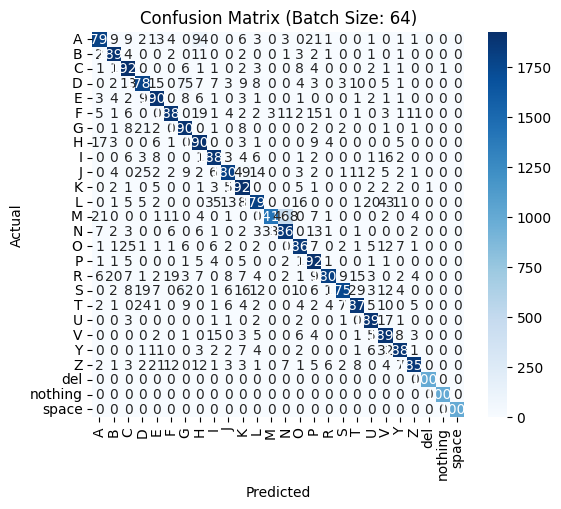

In [6]:
plt.figure(figsize=(10, 6))
for bs in results:
    plt.plot(results[bs]['loss'], label=f'Batch Size {bs}')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

best_bs = 128
best_f1 = 0

for bs in results:
    f1 = f1_score(results[bs]['true'], results[bs]['pred'], average='weighted')
    if f1 > best_f1:
        best_f1 = f1
        best_bs = bs

print(f"Best Batch Size: {best_bs} (F1-Score: {best_f1:.4f})")
print("-" * 60)
print(classification_report(results[best_bs]['true'], results[best_bs]['pred'], target_names=classes))

cm = confusion_matrix(results[best_bs]['true'], results[best_bs]['pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix (Batch Size: {best_bs})")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()